In [1]:
#type: ignore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from lightgbm import LGBMClassifier 
from sklearn.pipeline import Pipeline

In [2]:
train_path = "./data/train.csv" 
test_path = "./data/test.csv" 

train_data = pd.read_csv(train_path) 
test_data = pd.read_csv(train_path) 

In [12]:
SEED = 42
reviews = train_data['review']
target = train_data['target'] 

reviews_test = test_data['review'] 
target_test = test_data['target']

In [4]:
review_train, review_val, target_train, target_val = train_test_split(reviews, target, test_size=0.2, stratify=target, random_state=SEED) 

In [5]:
bow_vectorizer = CountVectorizer() 
tfidf_vectorizer = TfidfVectorizer() 

review_train_bow = bow_vectorizer.fit_transform(review_train) 
review_val_bow = bow_vectorizer.transform(review_val) 

review_train_tfidf = tfidf_vectorizer.fit_transform(review_train) 
review_val_tfidf = tfidf_vectorizer.transform(review_val) 

In [6]:
models = [ 
    LogisticRegression(n_jobs=-1, class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=SEED), 
    SVC(class_weight="balanced", random_state=SEED, decision_function_shape='ovr', cache_size=500), 
    MultinomialNB(), 
    LGBMClassifier(n_estimators=100, learning_rate=0.1, objective="multiclass", num_class=3, class_weight="balanced", random_state=SEED, n_jobs=-1), 
    RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),  
    LinearSVC(multi_class='ovr', class_weight='balanced', random_state=SEED)
]

In [8]:
import time
from sklearn.metrics import f1_score
data_types = {
    "BoW": (review_train_bow, review_val_bow), 
    "TF-IDF": (review_train_tfidf, review_val_tfidf) 
}

results = []

for data_name, (x_train, x_val) in data_types.items(): 
    for model in models: 
        model_name = model.__class__.__name__
        if isinstance(model, LGBMClassifier): 
            x_train = x_train.astype('float32')
            x_val = x_val.astype('float32')
        print(f"Train {model_name} with {data_name}...")

        start = time.time()
        model.fit(x_train, target_train)
        train_time = time.time() - start 

        y_pred = model.predict(x_val)

        results.append({
            "Model": model_name, 
            "Data Type": data_name,
            "Accuracy": round(accuracy_score(target_val, y_pred), 4), 
            "F1 (macro)": round(f1_score(target_val, y_pred, average="macro"), 4), 
            "F1 (weighted)": round(f1_score(target_val, y_pred, average="weighted"), 4), 
            "Train Time": round(train_time, 2)  
        })
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("F1 (macro)", ascending=False).reset_index(drop=True)

results_df.to_csv("./models_comparation.csv", index=False, encoding="utf-8") 
print(results_df.to_string(index=False))

Train LogisticRegression with BoW...


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train SVC with BoW...
Train MultinomialNB with BoW...
Train LGBMClassifier with BoW...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5703
[LightGBM] [Info] Number of data points in the train set: 43621, number of used features: 1788
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train RandomForestClassifier with BoW...
Train LinearSVC with BoW...
Train LogisticRegression with TF-IDF...


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Train SVC with TF-IDF...
Train MultinomialNB with TF-IDF...
Train LGBMClassifier with TF-IDF...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 84368
[LightGBM] [Info] Number of data points in the train set: 43621, number of used features: 1788
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


c:\Users\NinhDB\tiki-sentiment-analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train RandomForestClassifier with TF-IDF...
Train LinearSVC with TF-IDF...
                 Model Data Type  Accuracy  F1 (macro)  F1 (weighted)  Train Time
                   SVC       BoW    0.8400      0.6028         0.8465      324.99
                   SVC    TF-IDF    0.8529      0.6024         0.8534      315.95
             LinearSVC    TF-IDF    0.8435      0.5973         0.8470        0.88
             LinearSVC       BoW    0.8419      0.5922         0.8448       11.20
    LogisticRegression    TF-IDF    0.7865      0.5894         0.8178        1.55
    LogisticRegression       BoW    0.7986      0.5854         0.8243        2.67
        LGBMClassifier    TF-IDF    0.7672      0.5835         0.8063        6.66
        LGBMClassifier       BoW    0.7649      0.5801         0.8051        1.41
         MultinomialNB       BoW    0.8570      0.5418         0.8377        0.02
RandomForestClassifier    TF-IDF    0.8615      0.5242         0.8327        9.46
RandomForestClassifier 

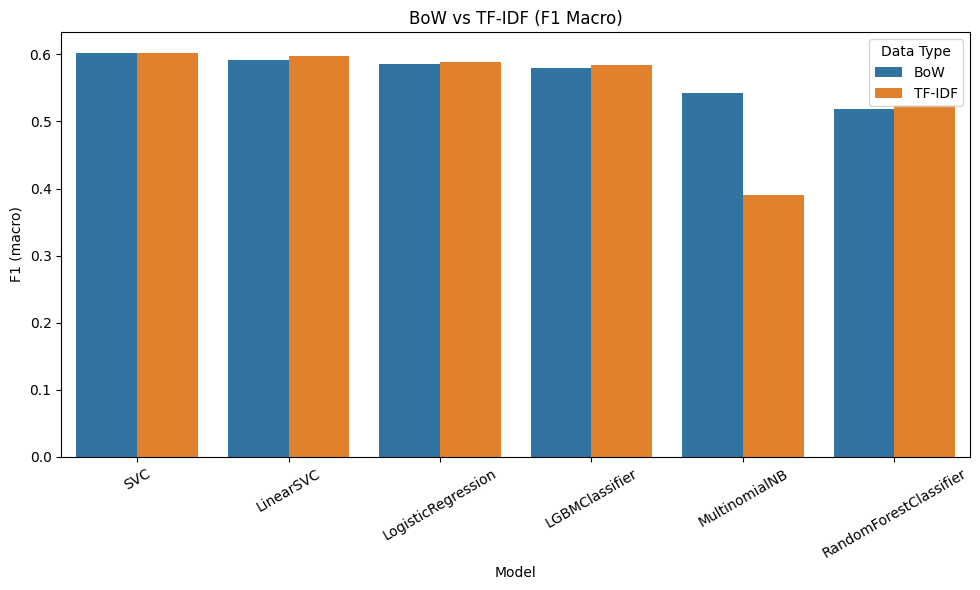

In [7]:
results_df = pd.read_csv("./models_comparation.csv")

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1 (macro)",
    hue="Data Type"
)

plt.title("BoW vs TF-IDF (F1 Macro)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

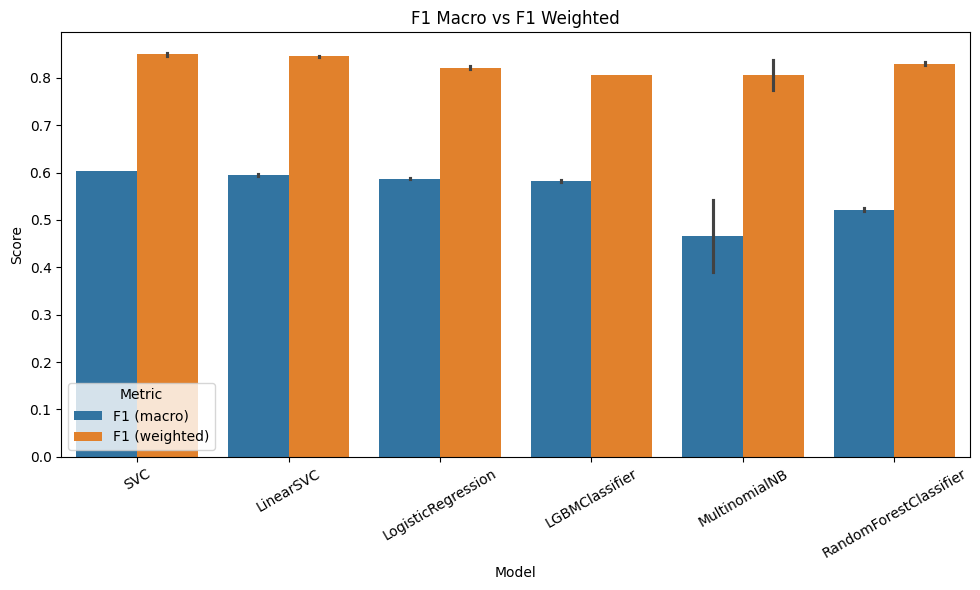

In [8]:
df_melt = results_df.melt(
    id_vars=["Model", "Data Type"],
    value_vars=["F1 (macro)", "F1 (weighted)"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_melt,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("F1 Macro vs F1 Weighted")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

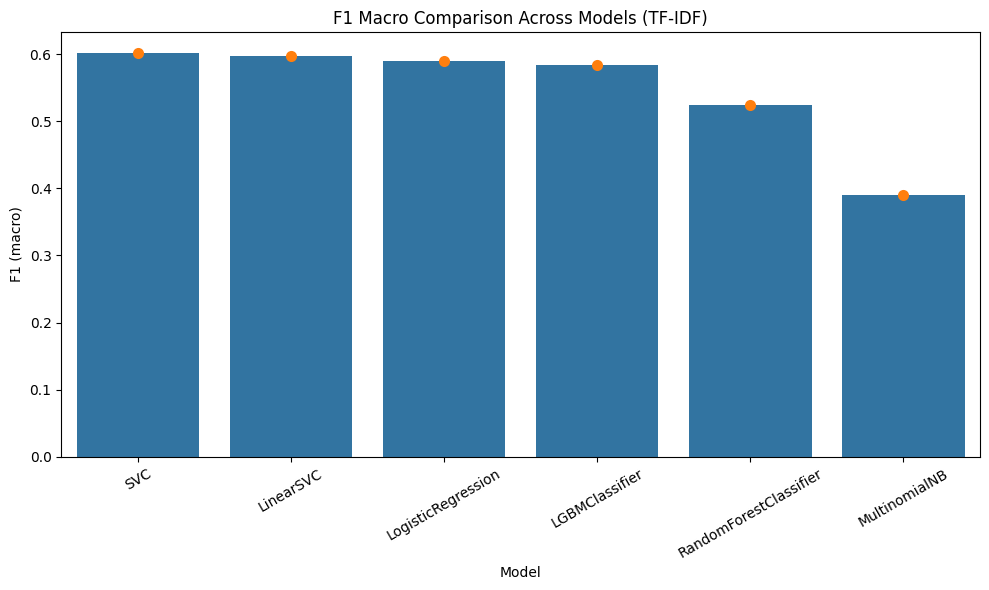

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# lọc TF-IDF
df_tfidf = results_df[results_df["Data Type"] == "TF-IDF"]

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_tfidf,
    x="Model",
    y="F1 (macro)"
)

sns.stripplot(
    data=df_tfidf,
    x="Model",
    y="F1 (macro)",
    size=8
)

plt.xticks(rotation=30)
plt.title("F1 Macro Comparison Across Models (TF-IDF)")
plt.tight_layout()
plt.show()

Tune parameters

In [22]:
import os
import joblib
LOG_PATH = "./grid_search_results.pkl"

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()), 
    ("svc", LinearSVC(multi_class='ovr', class_weight='balanced', random_state=SEED, max_iter=2000))
])

param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)], 
    'tfidf__sublinear_tf': [True, False], 
    'tfidf__min_df': [1,2,5], 
    'tfidf__max_df': [0.85, 0.95], 
    'svc__C': [0.01, 0.1, 1, 10, 100],  
}

if os.path.exists(LOG_PATH): 
    grid = joblib.load(LOG_PATH)
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   
    grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1) 
    grid.fit(review_train, target_train)
    joblib.dump(grid, LOG_PATH) 

scrore_df = pd.DataFrame(grid.cv_results_)
cols = [c for c in scrore_df.columns if 'param_' in c or c in ['mean_test_score', 'std_test_score', 'rank_test_score']]
scrore_df[cols].sort_values('rank_test_score').to_csv("grid_search_log.csv", index=False)

In [27]:
def plot_param_search(pipe, x, y, param_name, param_values, param_label=None, scoring="f1_macro", n_splits=5, ax=None, title=None): 
    means, stds = [], [] 
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for val in param_values: 
        pipe.set_params(**{param_name: val}) 
        scores = cross_val_score(pipe, x, y, cv=cv, scoring=scoring, n_jobs=-1)
        means.append(scores.mean())
        stds.append(scores.std())

    means = np.array(means) 
    stds = np.array(stds) 

    labels = param_label if param_label else [str(v) for v in param_values]
    best_indx = np.argmax(means)

    if ax is None: 
        _, ax = plt.subplots(figsize=(6,4))
    
    x = np.arange(len(labels)) 

    ax.fill_between(x, means-stds, means + stds, alpha=0.2, color='steelblue', label='± 1 std')
    ax.plot(x, means, 'o-', color='steelblue', linewidth=2, label='mean score') 
    ax.axvline(best_indx, color='tomato', linestyle='--', linewidth=1.5, label=f'best: {labels[best_indx]}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right') 
    ax.set_ylabel(scoring) 
    ax.set_title(title or param_name) 
    ax.legend(fontsize=8) 
    ax.grid(axis='y', alpha=0.3)
    print(f"[{param_name}] best = {labels[best_indx]}  "
          f"(mean={means[best_indx]:.4f}, std={stds[best_indx]:.4f})")
    return labels[best_indx], means[best_indx] 


[svc__C] best = 0.1  (mean=0.6098, std=0.0056)
[tfidf__ngram_range] best = (1,3), (1, 4)  (mean=0.5738, std=0.0041)
[tfidf__min_df] best = 1  (mean=0.5738, std=0.0041)
[tfidf__max_df] best = 0.7  (mean=0.5567, std=0.0027)


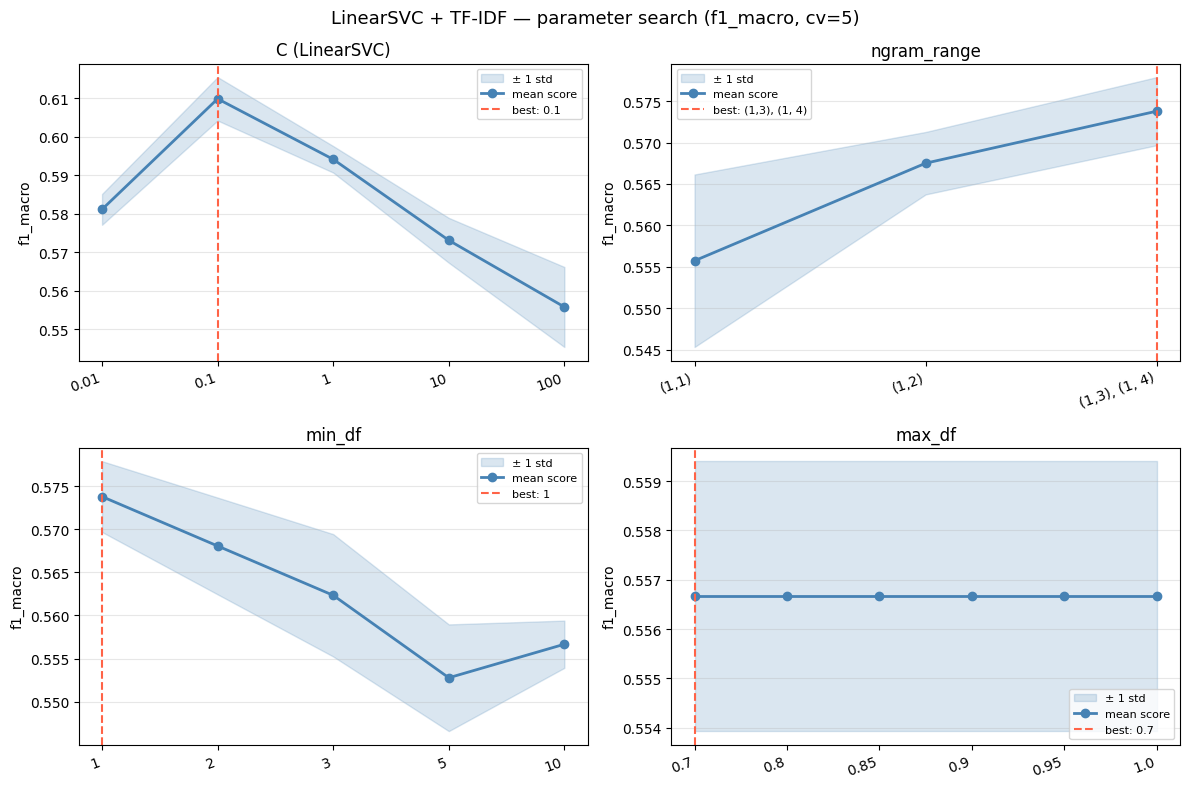

In [29]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer()), 
    ("svc", LinearSVC(multi_class='ovr', class_weight='balanced', random_state=SEED, max_iter=2000))
])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('LinearSVC + TF-IDF — parameter search (f1_macro, cv=5)', fontsize=13)

plot_param_search(pipe, review_train, target_train,
    param_name   = 'svc__C',
    param_values = [0.01, 0.1, 1, 10, 100],
    ax=axes[0, 0], title='C (LinearSVC)')

plot_param_search(pipe, review_train, target_train,
    param_name   = 'tfidf__ngram_range',
    param_values = [(1,1), (1,2), (1,3)],
    param_label = ['(1,1)', '(1,2)', '(1,3), (1, 4)'],
    ax=axes[0, 1], title='ngram_range')

plot_param_search(pipe, review_train, target_train,
    param_name   = 'tfidf__min_df',
    param_values = [1, 2, 3, 5, 10],
    ax=axes[1, 0], title='min_df')

plot_param_search(pipe, review_train, target_train,
    param_name   = 'tfidf__max_df',
    param_values = [0.7, 0.8, 0.85, 0.9, 0.95, 1.0],
    ax=axes[1, 1], title='max_df')

plt.tight_layout()
plt.savefig('param_search.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
model = LinearSVC(
    C=0.1, 
    multi_class="ovr", 
    class_weight="balanced", 
    max_iter=2000, 
    random_state=SEED
)
vectorizer = TfidfVectorizer(
    ngram_range=(1,3), 
    max_df = 0.7, 
    min_df = 1, 
    sublinear_tf=True 
)
pipeline = Pipeline ([
    ("tfidf", vectorizer), 
    ("classifier", model) 
])

Validation Dataset

In [15]:
pipeline.fit(review_train, target_train) 

y_pred_val = pipeline.predict(review_val) 

reporter = classification_report(target_val, y_pred_val)

print(reporter)

              precision    recall  f1-score   support

           0       0.60      0.77      0.67      1289
           1       0.29      0.17      0.21       689
           2       0.94      0.94      0.94      8928

    accuracy                           0.87     10906
   macro avg       0.61      0.62      0.61     10906
weighted avg       0.86      0.87      0.86     10906



In [16]:
y_pred_test = pipeline.predict(reviews_test) 

reporter = classification_report(target_test, y_pred_test)

print(reporter)

              precision    recall  f1-score   support

           0       0.79      0.90      0.84      6444
           1       0.81      0.69      0.75      3445
           2       0.97      0.96      0.97     44638

    accuracy                           0.94     54527
   macro avg       0.86      0.85      0.85     54527
weighted avg       0.94      0.94      0.94     54527



In [18]:
def plot_confusion_matrix(y_true, y_pred, figure_name='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis] * 100 
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
    disp.plot(cmap=plt.cm.Blues, values_format='.2f')
    plt.title(figure_name)
    plt.show()

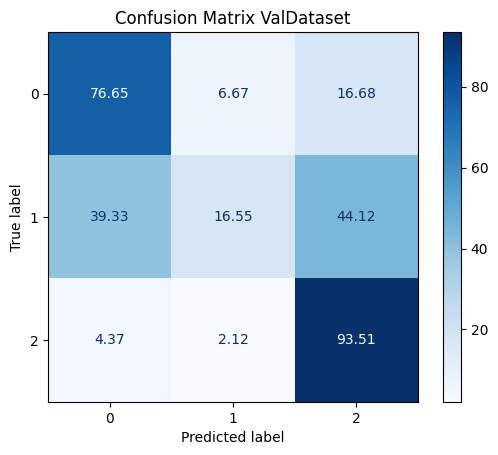

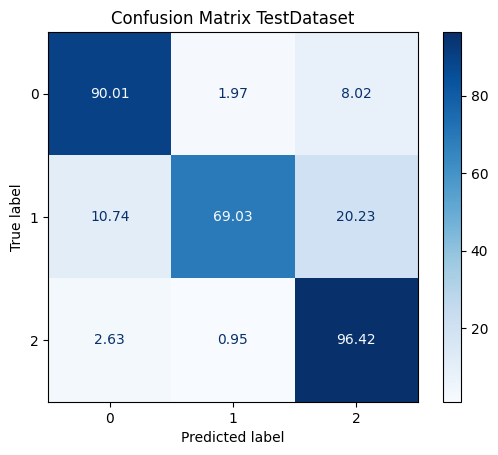

In [22]:
plot_confusion_matrix(target_val, y_pred_val, figure_name='Confusion Matrix ValDataset')
plot_confusion_matrix(target_test, y_pred_test, figure_name='Confusion Matrix TestDataset')

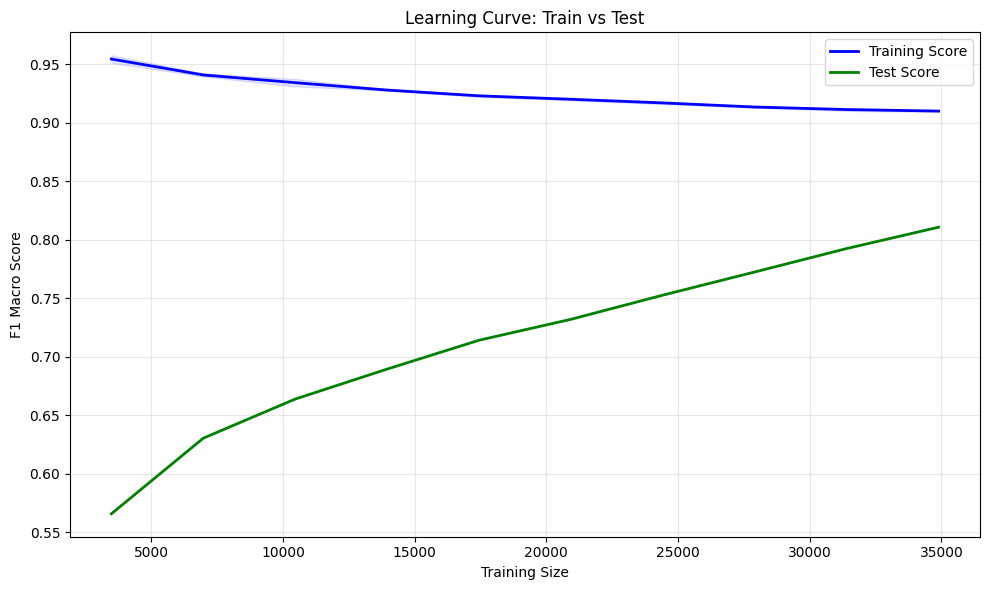

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

# Sử dụng pipeline đã train
pipeline.fit(review_train, target_train)

# Tính learning curve với train set
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, 
    review_train, 
    target_train, 
    cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Tính scores trên test set với các kích thước train khác nhau
test_scores = []
for size in train_sizes:
    # Train với subset có kích thước size
    pipeline_temp = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,3), max_df=0.7, min_df=1, sublinear_tf=True)), 
        ("classifier", LinearSVC(C=0.1, multi_class="ovr", class_weight="balanced", max_iter=2000, random_state=SEED))
    ])
    pipeline_temp.fit(review_train[:size], target_train[:size])
    score = f1_score(target_test, pipeline_temp.predict(reviews_test), average='macro')
    test_scores.append(score)

test_scores = np.array(test_scores)

# Biểu đồ 2: Train vs Test
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'b-', label='Training Score', linewidth=2)
plt.plot(train_sizes, test_scores, 'g-', label='Test Score', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.xlabel('Training Size')
plt.ylabel('F1 Macro Score')
plt.title('Learning Curve: Train vs Test')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
import joblib
joblib.dump(pipeline, "./sentiment_pipeline.pkl")

['./sentiment_pipeline.pkl']